# 09-High-Definition Observability (Grafana)

In Lesson 08, we instrumented our Generative AI application to expose mathematical telemetry and deployed **Prometheus** to scrape these vectors via a Pull Model. Prometheus is a phenomenal time-series database and calculation engine, but it is not designed for human operational awareness. Staring at raw PromQL queries and naked arrays during a 3:00 AM system outage results in cognitive overload and slow incident triage.

To engineer absolute operational intelligence, we must decouple the *storage* of metrics from the *presentation* of metrics. We implement **Grafana**, the industry-standard visualization engine. Grafana connects directly to the Prometheus backend, projecting complex multi-dimensional time-series vectors into high-definition, interactive visual topologies.

Furthermore, in Enterprise MLOps, we do not click through user interfaces to build dashboards. We define our visual layers using **Dashboard-as-Code**, ensuring that our executive intelligence screens are version-controlled, immutable, and instantly reproducible across global clusters.

## 1. The Mathematics of Visual Topology (PromQL to Pixels)

### Dimensional Aggregation ($\Sigma$)

In a distributed ML cluster, you might have 50 parallel GPU containers running `llama-3-8b`. Prometheus scrapes the token generation counter for each isolated container. To visualize the total cluster throughput in Grafana, we must mathematically aggregate the vectors across the container dimension, grouping strictly by the model name.

The total Tokens Per Second (TPS) across the entire fleet is the sum of the derivatives of the individual container vectors:


$$\text{Total TPS} = \sum_{\text{container } i=1}^{N} \frac{d}{dt} \left( \text{Tokens}_i(t) \right)$$


In Grafana, we bind this mathematical reality to a visual graph panel using PromQL aggregation:
`sum by (model_name) (rate(llm_tokens_generated_total[1m]))`

### The SLA Boundary Constraint

A dashboard is useless if it does not visually separate healthy states from critical failures. We mathematically define the **Service Level Agreement (SLA)** as a strict constant scalar threshold $k$.

For a latency panel plotting $P_{99}$ response times, we introduce a static threshold vector:


$$y_{sla}(t) = k \quad \forall t$$


If the PromQL vector $y_{p99}(t) > y_{sla}(t)$, Grafana mathematically intercepts the intersection point and triggers a visual state change (e.g., flipping the graph topology from Green to Red).

### Histogram Heatmaps (The Distribution Matrix)

Plotting a single line for "Average Output Length" obscures the truth. Grafana can visualize Prometheus Histograms as **Heatmaps**, plotting Time on the X-axis, Token Buckets on the Y-axis, and Density (Frequency) on the Z-axis (Color Intensity). This allows MLOps engineers to instantly spot if a specific subset of users is generating massive 8,000-token outputs while the majority generates 50 tokens.

## 2. Declarative Execution: Booting the Visualization Layer

We will define a local, zero-cost Docker Compose matrix that deploys Grafana, strictly binding it to the Prometheus network we engineered in Lesson 08.

In [4]:
import os
import yaml
import numpy as np

print("--- 🚀 Initializing High-Definition Observability Matrix ---")

grafana_sandbox = "./grafana_sandbox"
os.makedirs(grafana_sandbox, exist_ok=True)

# 📝 Define the Grafana + Prometheus Infrastructure Blueprint
observability_compose = {
    "version": "3.8",
    "services": {
        "prometheus": {
            "image": "prom/prometheus:latest",
            "container_name": "mlops_prometheus_core",
            "ports": ["9090:9090"]
        },
        "grafana": {
            "image": "grafana/grafana:latest",
            "container_name": "mlops_grafana_ui",
            "ports": ["3000:3000"],
            "environment": [
                "GF_SECURITY_ADMIN_PASSWORD=secure_admin_2026",
                "GF_USERS_ALLOW_SIGN_UP=false" # Enforce strict access control
            ],
            "depends_on": ["prometheus"] # DAG Edge: Prometheus must boot first
        }
    }
}

compose_path = os.path.join(grafana_sandbox, "docker-compose.yml")
with open(compose_path, "w") as f:
    yaml.dump(observability_compose, f, default_flow_style=False)

print(f"   ✅ Declarative Infrastructure Matrix Compiled: {compose_path}")

--- 🚀 Initializing High-Definition Observability Matrix ---
   ✅ Declarative Infrastructure Matrix Compiled: ./grafana_sandbox/docker-compose.yml


## 3. Imperative Execution: Dashboard-as-Code (JSON Provisioning)

We will not configure our ML Dashboard by manually clicking in the Grafana UI. We will write a Python script that programmatically compiles the exact visual layout into a structured JSON payload. This JSON can be automatically injected into Grafana's API via a CI/CD pipeline.

In [5]:
import json

print("\n--- ⚡ Compiling Dashboard-as-Code (JSON Provisioning) ---")

# 1. Compile the strict JSON topology for a standard MLOps Dashboard
mlops_dashboard_json = {
    "dashboard": {
        "id": None,
        "title": "LLM Inference Fleet Overview",
        "tags": ["mlops", "production", "llm"],
        "timezone": "browser",
        "schemaVersion": 30,
        "panels": [
            {
                "title": "Aggregate Tokens Per Second (TPS)",
                "type": "timeseries",
                "gridPos": {"h": 8, "w": 12, "x": 0, "y": 0}, # Exact coordinate placement
                "targets": [
                    {
                        "expr": "sum by (model_name) (rate(llm_tokens_generated_total[1m]))",
                        "legendFormat": "{{model_name}} TPS"
                    }
                ],
                "fieldConfig": {
                    "defaults": {
                        "color": {"mode": "palette-classic"},
                        "custom": {"fillOpacity": 10, "lineWidth": 2}
                    }
                }
            },
            {
                "title": "P99 GPU Latency vs SLA",
                "type": "timeseries",
                "gridPos": {"h": 8, "w": 12, "x": 12, "y": 0},
                "targets": [
                    {
                        "expr": "histogram_quantile(0.99, sum(rate(llm_latency_seconds_bucket[1m])) by (le))",
                        "legendFormat": "P99 Latency (Seconds)"
                    }
                ],
                "fieldConfig": {
                    "defaults": {
                        "thresholds": {
                            "mode": "absolute",
                            "steps": [
                                {"color": "green", "value": None},
                                {"color": "red", "value": 2.5} # Hard SLA limit at 2.5 seconds
                            ]
                        }
                    }
                }
            }
        ]
    },
    "overwrite": True
}

dashboard_path = os.path.join(grafana_sandbox, "llm_dashboard.json")
with open(dashboard_path, "w") as f:
    json.dump(mlops_dashboard_json, f, indent=4)

print(f"   ✅ Dashboard JSON compiled: {dashboard_path}")
print("   -> Physics: This JSON completely dictates the visual rendering engine.")
print("\n--- 🛠️ Operational Boot Instructions ---")
print("To boot the visualization layer on your workstation:")
print(f"   1. cd {grafana_sandbox} && docker compose up -d")
print("   2. Open http://localhost:3000 in your browser (Login: admin / secure_admin_2026)")
print("   3. Import the generated JSON file to instantly materialize the MLOps layout.")


--- ⚡ Compiling Dashboard-as-Code (JSON Provisioning) ---
   ✅ Dashboard JSON compiled: ./grafana_sandbox/llm_dashboard.json
   -> Physics: This JSON completely dictates the visual rendering engine.

--- 🛠️ Operational Boot Instructions ---
To boot the visualization layer on your workstation:
   1. cd ./grafana_sandbox && docker compose up -d
   2. Open http://localhost:3000 in your browser (Login: admin / secure_admin_2026)
   3. Import the generated JSON file to instantly materialize the MLOps layout.


## 4. Visualizing the Dashboard Topology (Visual Hierarchy)

To engineer an effective dashboard, we must respect human cognitive physics. Critical, aggregated numbers sit at the top. Time-series trends sit in the middle. Granular, highly-cardinal hardware data sits at the bottom. Let's visualize this structural grid.

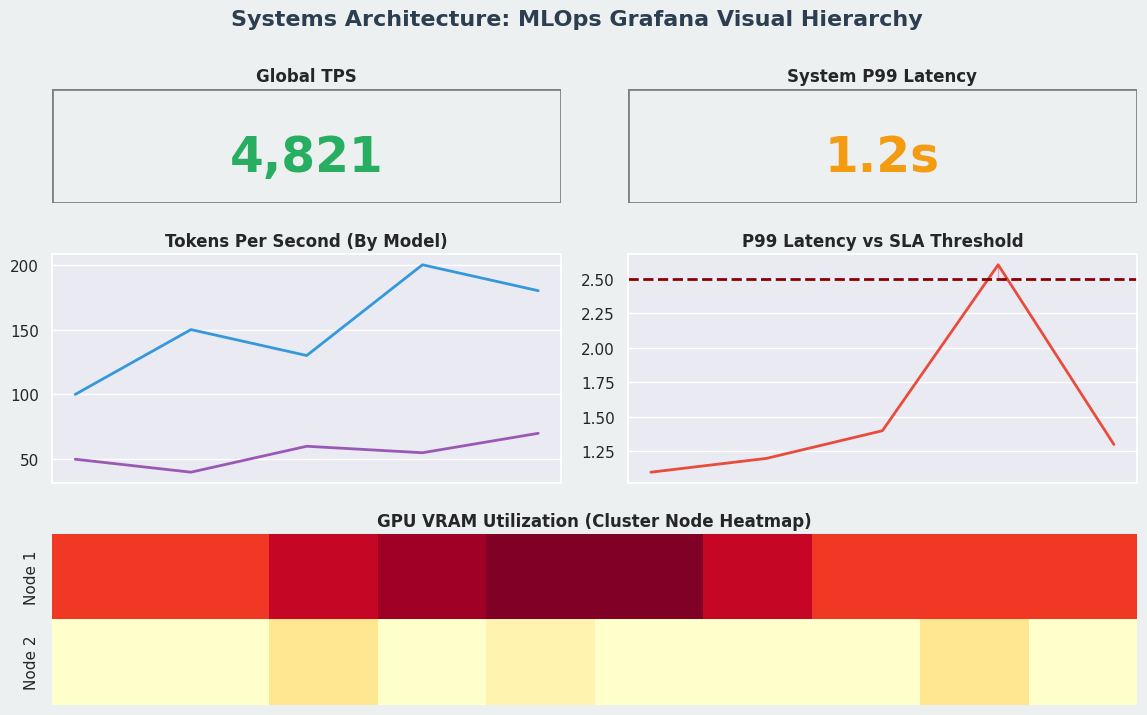

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="darkgrid")

# Create a master visual canvas representing a 1920x1080 Monitor Screen
fig = plt.figure(figsize=(14, 8))
fig.suptitle("Systems Architecture: MLOps Grafana Visual Hierarchy", fontsize=16, fontweight='bold', color='#2c3e50')
fig.patch.set_facecolor('#ecf0f1') # Light gray dashboard background

# Define a strict Grid layout (GridSpec) simulating Grafana panel positioning
gs = gridspec.GridSpec(3, 4, figure=fig, height_ratios=[1, 2, 1.5], hspace=0.3, wspace=0.3)

# --- TIER 1: Executive Summary (Stat Panels / Single Numbers) ---
# High cognitive visibility, answers "Is the system alive?" instantly.
ax_stat1 = fig.add_subplot(gs[0, 0:2])
ax_stat1.set_title("Global TPS", fontweight='bold')
ax_stat1.text(0.5, 0.4, "4,821", ha='center', va='center', fontsize=35, color='#27ae60', fontweight='bold')
ax_stat1.axis('off')
ax_stat1.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='gray', transform=ax_stat1.transAxes, lw=2))

ax_stat2 = fig.add_subplot(gs[0, 2:4])
ax_stat2.set_title("System P99 Latency", fontweight='bold')
ax_stat2.text(0.5, 0.4, "1.2s", ha='center', va='center', fontsize=35, color='#f39c12', fontweight='bold')
ax_stat2.axis('off')
ax_stat2.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='gray', transform=ax_stat2.transAxes, lw=2))

# --- TIER 2: Time-Series Vectors (Trend Analysis) ---
# Answers "How is the system behaving over time?"
ax_ts1 = fig.add_subplot(gs[1, 0:2])
ax_ts1.set_title("Tokens Per Second (By Model)", fontweight='bold')
ax_ts1.plot([1, 2, 3, 4, 5], [100, 150, 130, 200, 180], color='#3498db', lw=2)
ax_ts1.plot([1, 2, 3, 4, 5], [50, 40, 60, 55, 70], color='#9b59b6', lw=2)
ax_ts1.set_xticks([])

ax_ts2 = fig.add_subplot(gs[1, 2:4])
ax_ts2.set_title("P99 Latency vs SLA Threshold", fontweight='bold')
ax_ts2.plot([1, 2, 3, 4, 5], [1.1, 1.2, 1.4, 2.6, 1.3], color='#e74c3c', lw=2)
ax_ts2.axhline(2.5, color='darkred', linestyle='--', lw=2) # SLA Boundary
ax_ts2.fill_between([1, 2, 3, 4, 5], [1.1, 1.2, 1.4, 2.6, 1.3], 2.5, where=([1.1, 1.2, 1.4, 2.6, 1.3] > np.array([2.5])), color='red', alpha=0.3)
ax_ts2.set_xticks([])

# --- TIER 3: Node-Level Granularity (Hardware Diagnostics) ---
# Answers "Which specific piece of hardware is causing the problem?"
ax_hw = fig.add_subplot(gs[2, :])
ax_hw.set_title("GPU VRAM Utilization (Cluster Node Heatmap)", fontweight='bold')
# Simulated VRAM Heatmap (4 Nodes, 10 Time Steps)
sns.heatmap([[0.8, 0.8, 0.9, 0.95, 0.99, 0.99, 0.9, 0.8, 0.8, 0.8],
             [0.4, 0.4, 0.5, 0.4, 0.45, 0.4, 0.4, 0.4, 0.5, 0.4]], 
            cmap="YlOrRd", cbar=False, ax=ax_hw, yticklabels=['Node 1', 'Node 2'])
ax_hw.set_xticks([])

plt.show()

*(Insight: When the P99 Latency breaches the 2.5s SLA boundary in Tier 2, the MLOps engineer immediately drops their eyes to Tier 3. The heatmap instantly reveals that Node 1's VRAM maxed out at 99%, proving that the latency spike is due to memory saturation, not a network failure. Grafana makes this diagnosis visual and instantaneous.)*

## Real-World Use Case or Analogy

Think of Prometheus vs. Grafana like **An Airplane's Internal Telemetry Wiring vs. The Glass Cockpit Display**:

* **Prometheus (The Internal Wiring):** Deep inside a Boeing 777, millions of electrical pulses are transmitted every second. There is a raw voltage reading for the left engine oil pressure, the right engine fuel flow, and the cabin altitude. If you placed a pilot in the electronics bay and told them to fly the plane by reading the raw binary voltage numbers off the circuit boards (**Reading raw PromQL queries**), the plane would crash immediately.
* **Grafana (The Glass Cockpit):** The glass cockpit sits in front of the pilot. It ingests all those millions of raw voltage numbers and projects them onto high-definition LCD screens.
* Instead of raw numbers, it shows an artificial horizon and a green throttle bar (**Time-series panels**).
* If the left engine oil pressure drops below the mathematical safety threshold (**The SLA Limit**), the screen instantly flashes a massive red warning block (**Threshold Alerting**).



By layering Grafana over Prometheus, MLOps engineers transform raw, incomprehensible mathematical arrays into an intuitive visual operating system, allowing human operators to safely pilot multi-million-dollar AI infrastructure at supersonic speeds.